Google just released [Gemma 4](https://blog.google/innovation-and-ai/technology/developers-tools/gemma-4/) — open-weight models (Apache 2.0) available directly through the Gemini API. Same SDK, same API key — just change the model name.

| Model | Type | Size |
|-------|------|------|
| `gemini-3.1-pro-preview` | Closed | Large |
| `gemini-3.1-flash-lite-preview` | Closed | Small |
| `gemma-4-31b-it` | Open | 31B dense |
| `gemma-4-26b-a4b-it` | Open | 26B MoE (4B active) |

In [1]:
import os, json, re, time, asyncio
from google import genai
from google.genai import types
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

client = genai.Client(api_key=os.environ['GEMINI_API_KEY'])

MODELS = [
    "gemini-3.1-pro-preview",
    "gemini-3.1-flash-lite-preview",
    "gemma-4-31b-it",
    "gemma-4-26b-a4b-it",
]
SHORT = {m: m for m in MODELS}

%config InlineBackend.figure_format = 'retina'

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


## Available Models

In [2]:
rows = []
for m in client.models.list():
    if any(k in m.name.lower() for k in ['gemma-4', 'gemini-3']):
        rows.append({"Model": m.name, "Input": f"{m.input_token_limit:,}", "Output": f"{m.output_token_limit:,}"})
pd.DataFrame(rows).style.hide(axis='index')

Model,Input,Output
models/gemma-4-26b-a4b-it,"262,144","32,768"
models/gemma-4-31b-it,"262,144","32,768"
models/gemini-3-pro-preview,"1,048,576","65,536"
models/gemini-3-flash-preview,"1,048,576","65,536"
models/gemini-3.1-pro-preview,"1,048,576","65,536"
models/gemini-3.1-pro-preview-customtools,"1,048,576","65,536"
models/gemini-3.1-flash-lite-preview,"1,048,576","65,536"
models/gemini-3-pro-image-preview,"131,072","32,768"
models/gemini-3.1-flash-image-preview,"65,536","65,536"
models/gemini-3.1-flash-live-preview,"131,072","65,536"


## Async Comparison Helper

Calling 4 models sequentially is slow (Gemma can take 60-100s). We call them **all in parallel** using `client.aio`.

In [3]:
async def _call_one(model, parts, config=None):
    t0 = time.time()
    try:
        kw = {"model": model, "contents": parts}
        if config:
            kw["config"] = config
        resp = await client.aio.models.generate_content(**kw)
        dt = time.time() - t0
        u = resp.usage_metadata
        return model, {
            "response": resp.text or "[empty]",
            "time_s": dt, "time": f"{dt:.1f}s",
            "in_tok": u.prompt_token_count if u else 0,
            "out_tok": u.candidates_token_count if u else 0,
        }
    except Exception as e:
        return model, {"response": f"**Error**: {e}", "time_s":0, "time":"err", "in_tok":0, "out_tok":0}


def compare(prompt, images=None, display_images=True, config=None):
    """Run prompt on all models in parallel."""
    if images and display_images:
        n = len(images)
        fig, axes = plt.subplots(1, n, figsize=(4*n, 3))
        if n == 1: axes = [axes]
        for ax, img in zip(axes, images):
            ax.imshow(img); ax.axis('off')
        plt.tight_layout(); plt.show()

    parts = list(images or []) + [prompt]
    t0 = time.time()

    async def _go():
        return dict(await asyncio.gather(*[_call_one(m, parts, config) for m in MODELS]))

    try:
        loop = asyncio.get_running_loop()
        import nest_asyncio; nest_asyncio.apply()
        results = loop.run_until_complete(_go())
    except RuntimeError:
        results = asyncio.run(_go())

    wall = time.time() - t0
    seq = sum(r['time_s'] for r in results.values())

    for model, r in results.items():
        text = r['response'][:2000] + "\n*[truncated]*" if len(r['response']) > 2000 else r['response']
        display(Markdown(f"**{SHORT[model]}** &nbsp;|&nbsp; {r['time']} &nbsp;|&nbsp; {r['out_tok']} tok"))
        display(Markdown(text))

    print(f"\n\u23f1 Wall: {wall:.1f}s (parallel) vs {seq:.1f}s (sequential would be)")
    return results

## Task 1: Scene Understanding

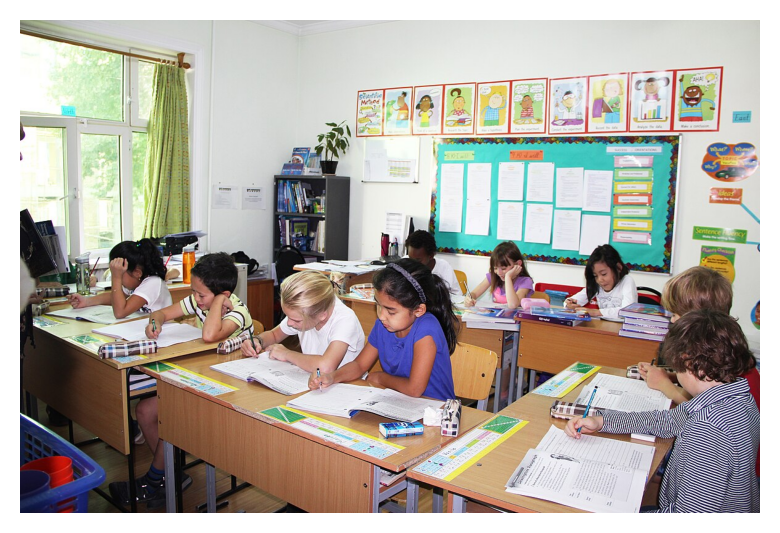

**gemini-3.1-pro-preview** &nbsp;|&nbsp; 12.1s &nbsp;|&nbsp; 84 tok

In a brightly lit classroom, several elementary school students are sitting at wooden desks, quietly focused on reading and writing assignments. The children have open notebooks, loose worksheets, pencil cases, and pens spread out in front of them as they work. The background features a large window with green curtains, a black bookshelf filled with materials, a green bulletin board, and a row of colorful educational posters lining the top of the wall.

**gemini-3.1-flash-lite-preview** &nbsp;|&nbsp; 2.3s &nbsp;|&nbsp; 54 tok

In this classroom, a group of students sits at wooden desks, intently focused on writing in their workbooks. The room is decorated with educational posters, charts, and bookshelves, and there are various school supplies like pens, notebooks, and pencil cases scattered on the desks.

**gemma-4-31b-it** &nbsp;|&nbsp; 8.4s &nbsp;|&nbsp; 59 tok

A group of students are sitting at desks in a classroom, focused on writing in their notebooks. The room is filled with wooden desks and chairs, and the walls are decorated with various colorful educational posters and drawings. In the background, there is a bookshelf and a large window with light-colored curtains.

**gemma-4-26b-a4b-it** &nbsp;|&nbsp; 17.7s &nbsp;|&nbsp; 47 tok

Several children are sitting at desks in a brightly lit classroom, focused on writing in their notebooks and reading books. The room is filled with various school supplies, including pens, pencils, and folders, while colorful educational posters decorate the walls.


⏱ Wall: 17.7s (parallel) vs 40.5s (sequential would be)


In [4]:
results_scene = compare(
    "Describe this image in 2-3 sentences. What is happening and what objects do you see?",
    images=[Image.open("classroom.jpg")],
)

## Task 2: Chart Analysis

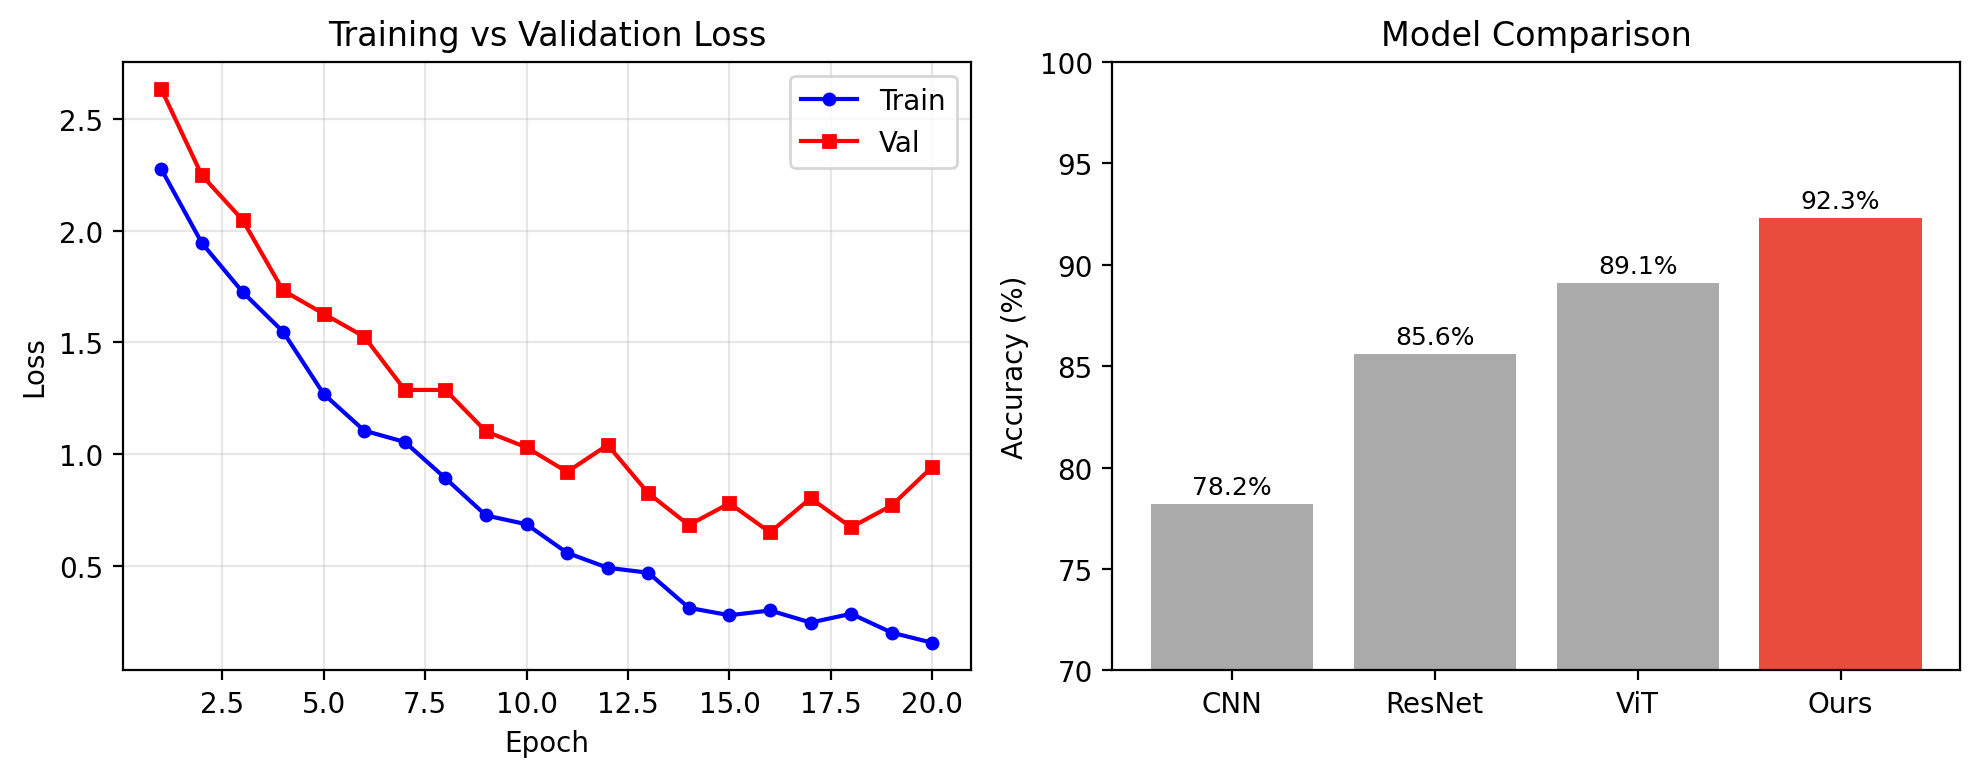

In [5]:
np.random.seed(42)
epochs = np.arange(1, 21)
train_loss = 2.5 * np.exp(-0.15 * epochs) + 0.1 + np.random.normal(0, 0.05, 20)
val_loss = 2.5 * np.exp(-0.12 * epochs) + 0.3 + np.random.normal(0, 0.08, 20)
val_loss[14:] += np.linspace(0, 0.4, 6)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(epochs, train_loss, 'b-o', label='Train', ms=4)
ax1.plot(epochs, val_loss, 'r-s', label='Val', ms=4)
ax1.set(xlabel='Epoch', ylabel='Loss', title='Training vs Validation Loss')
ax1.legend(); ax1.grid(True, alpha=0.3)

bars = ['CNN', 'ResNet', 'ViT', 'Ours']
acc = [78.2, 85.6, 89.1, 92.3]
ax2.bar(bars, acc, color=['#aaa','#aaa','#aaa','#e74c3c'])
ax2.set(ylabel='Accuracy (%)', title='Model Comparison', ylim=(70,100))
for i, v in enumerate(acc): ax2.text(i, v+0.5, f'{v}%', ha='center', fontsize=9)
plt.tight_layout()
fig.savefig('/tmp/research_plot.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
results_chart = compare(
    """Analyze these two plots concisely:
1. Left: what does it show and at which epoch does overfitting begin?
2. Right: which model is best and by how much over the runner-up?""",
    images=[Image.open('/tmp/research_plot.png')],
    display_images=False,
)

**gemini-3.1-pro-preview** &nbsp;|&nbsp; 13.3s &nbsp;|&nbsp; 126 tok

Based on the plots provided:

1.  **Left (Training vs Validation Loss):** It displays the model's loss decreasing over 20 epochs. Overfitting begins at **epoch 16**; this is the point where the validation loss reaches its minimum and begins to rise in subsequent epochs, while the training loss continues to decrease.
2.  **Right (Model Comparison):** The **"Ours"** model performs the best. It beats the runner-up model (ViT) by **3.2 percentage points** (92.3% vs 89.1%).

**gemini-3.1-flash-lite-preview** &nbsp;|&nbsp; 3.1s &nbsp;|&nbsp; 129 tok

Based on the provided charts:

1.  **Training vs. Validation Loss:** This plot displays the progression of training and validation loss over 20 epochs. The training loss decreases consistently throughout. Overfitting begins around **epoch 12**, where the validation loss stops its steady decline and starts to fluctuate and increase, while the training loss continues to drop.
2.  **Model Comparison:** The **"Ours"** model is the best performer with an accuracy of **92.3%**. It outperforms the runner-up (ViT, at 89.1%) by **3.2 percentage points**.

**gemma-4-31b-it** &nbsp;|&nbsp; 18.0s &nbsp;|&nbsp; 96 tok

1. **Left Plot:** It shows the training and validation loss over 20 epochs. Overfitting begins at approximately **epoch 12.5**, where the validation loss starts to increase while the training loss continues to decrease.
2. **Right Plot:** The **"Ours"** model is the best with 92.3% accuracy, outperforming the runner-up (VIT, 89.1%) by **3.2%**.

**gemma-4-26b-a4b-it** &nbsp;|&nbsp; 16.8s &nbsp;|&nbsp; 105 tok

Based on the plots provided:

1.  **Left Plot:** It shows the **training and validation loss** over 20 epochs. Overfitting begins at **epoch 13**, as this is the point where the validation loss starts to increase while the training loss continues to decrease.
2.  **Right Plot:** The **"Ours"** model is the best, with an accuracy of 92.3%. It outperforms the runner-up (VIT) by **3.2%**.


⏱ Wall: 18.0s (parallel) vs 51.1s (sequential would be)


## Task 3: Segmentation

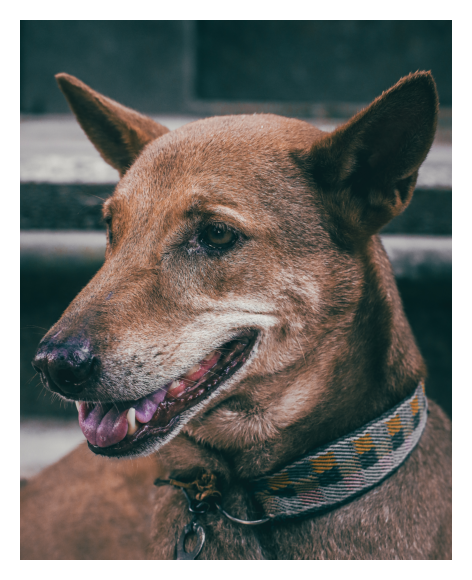

**gemini-3.1-pro-preview** &nbsp;|&nbsp; 7.5s &nbsp;|&nbsp; 390 tok

```json
{"polygon": [[87, 240], [185, 148], [300, 116], [502, 172], [711, 201], [764, 126], [839, 102], [931, 107], [956, 176], [903, 273], [819, 360], [860, 521], [888, 597], [923, 678], [980, 755], [978, 936], [886, 966], [830, 977], [757, 986], [667, 982], [572, 974], [437, 976], [320, 978], [357, 856], [314, 824], [252, 814], [150, 775], [178, 736], [228, 725], [148, 707], [63, 646], [42, 606], [65, 552], [140, 501], [171, 451], [195, 370], [190, 311], [103, 252]], "label": "dog"}
```

**gemini-3.1-flash-lite-preview** &nbsp;|&nbsp; 4.0s &nbsp;|&nbsp; 199 tok

{"polygon": [[242, 63], [376, 178], [579, 175], [784, 91], [941, 120], [973, 230], [980, 502], [978, 866], [870, 966], [676, 959], [427, 984], [183, 984], [34, 856], [30, 663], [75, 597], [163, 560], [289, 584], [328, 412], [284, 303], [242, 144]]}

**gemma-4-31b-it** &nbsp;|&nbsp; 114.8s &nbsp;|&nbsp; 395 tok

```json
{"polygon": [[87, 111], [134, 133], [184, 187], [300, 178], [462, 165], [608, 178], [698, 134], [780, 85], [865, 93], [945, 121], [962, 199], [930, 280], [865, 324], [846, 403], [870, 498], [907, 647], [937, 800], [942, 948], [803, 987], [600, 996], [400, 988], [200, 961], [45, 910], [12, 795], [42, 651], [102, 677], [177, 732], [302, 743], [417, 712], [516, 673], [430, 640], [200, 630], [38, 608], [55, 550], [125, 477], [225, 399], [300, 348], [220, 250], [87, 111]], "label": "dog"}
```

**gemma-4-26b-a4b-it** &nbsp;|&nbsp; 55.9s &nbsp;|&nbsp; 207 tok

```json
{"polygon": [[98, 120], [228, 267], [206, 521], [95, 964], [325, 877], [445, 834], [593, 892], [756, 948], [995, 992], [995, 2], [774, 341], [795, 279], [782, 183], [711, 110], [580, 35], [521, 54], [432, 175], [321, 258], [150, 137], [98, 120]], "label": "dog"}
```


⏱ Wall: 114.9s (parallel) vs 182.3s (sequential would be)


In [7]:
seg_img = Image.open('happy-doggy.jpg')

results_seg = compare(
    """Segment the main animal in this image.
Return JSON: {"polygon": [[x1,y1], [x2,y2], ...], "label": "..."}
Coordinates in [0, 1000] range. Use 20+ points.
Return ONLY valid JSON.""",
    images=[seg_img],
)

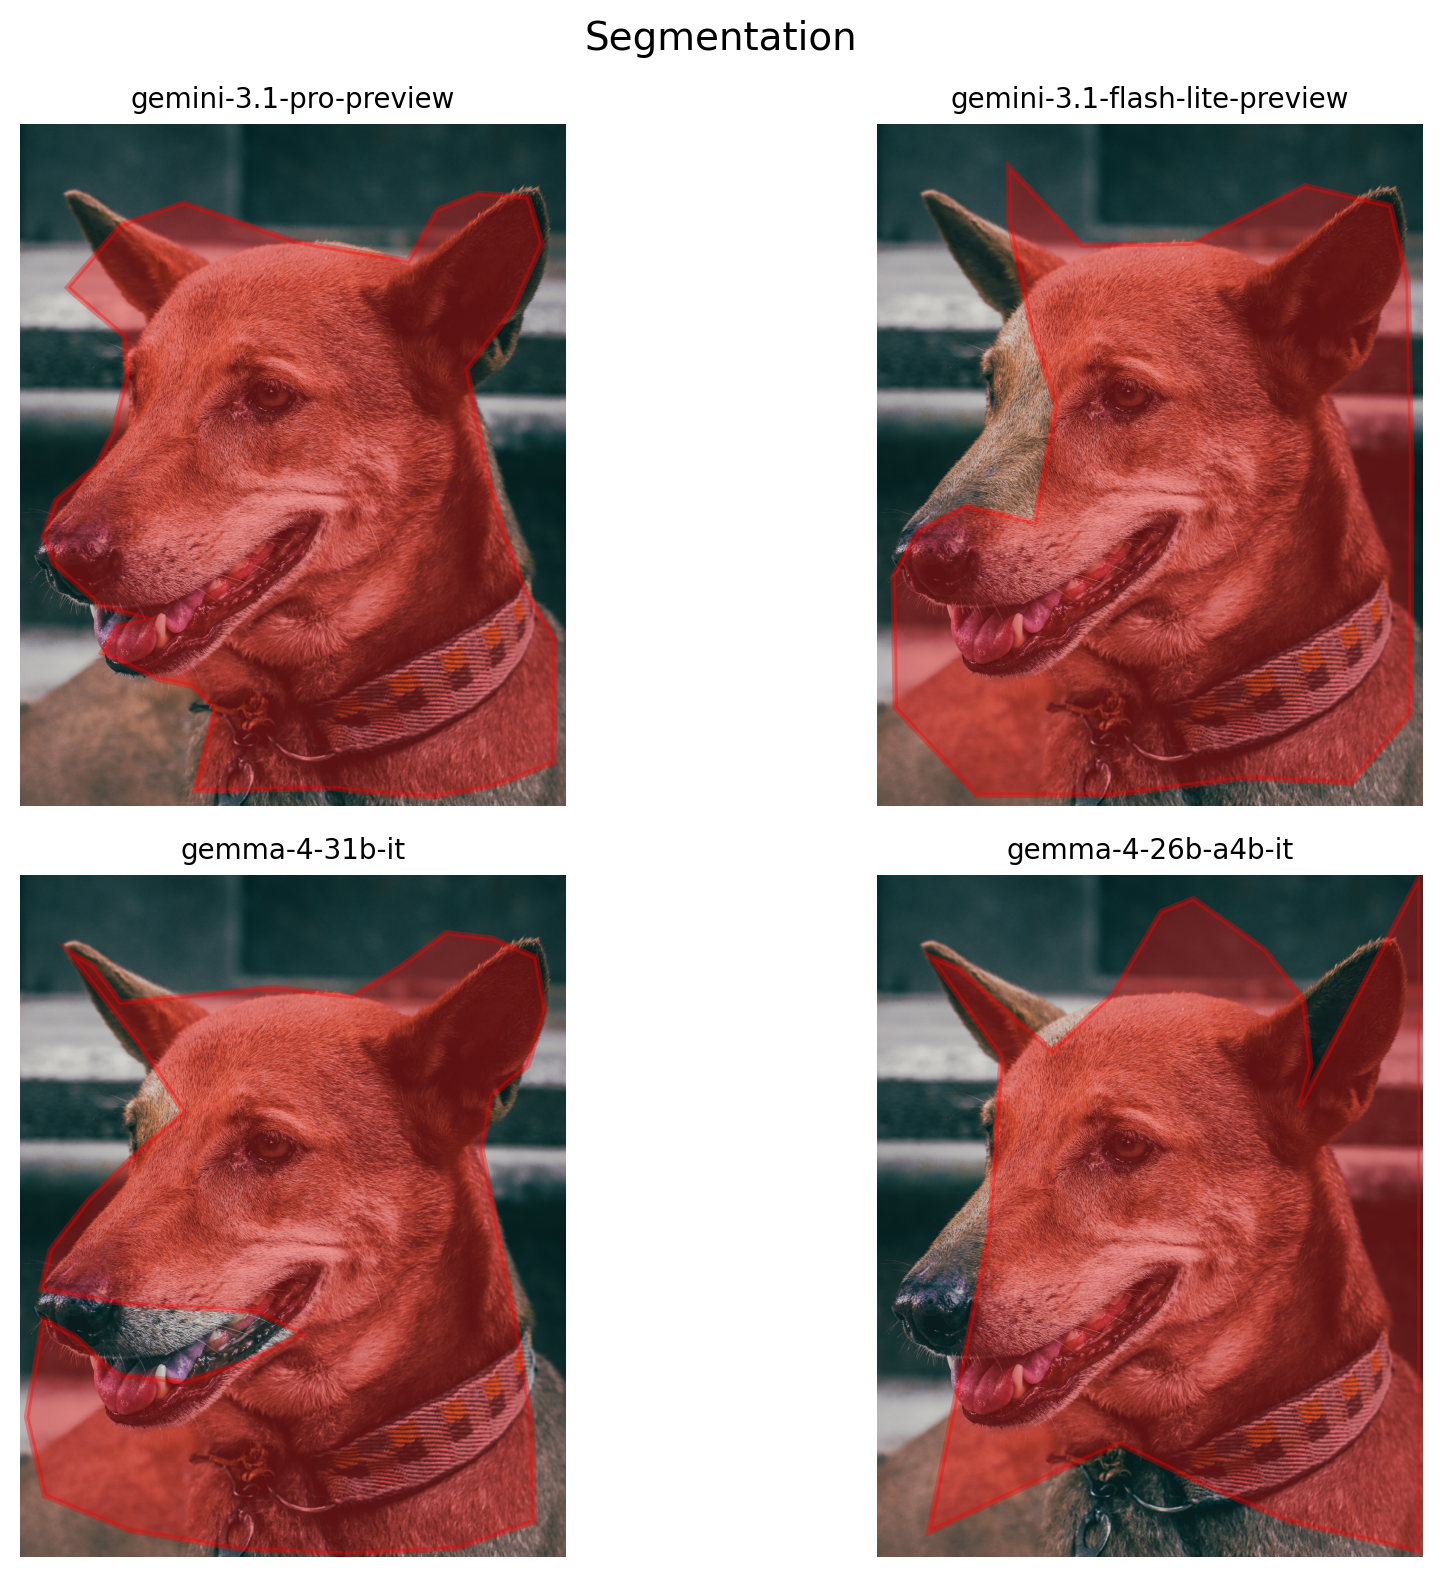

In [8]:
from matplotlib.patches import Polygon as MPLPoly

img_np = np.array(seg_img); h, w = img_np.shape[:2]
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for ax, model in zip(axes.flat, MODELS):
    ax.set_title(SHORT[model], fontsize=10); ax.imshow(img_np)
    try:
        raw = results_seg[model]['response'].strip()
        raw = re.sub(r'```json\s*', '', raw)
        raw = re.sub(r'```', '', raw)
        m = re.search(r'\{.*\}', raw, re.DOTALL)
        seg = json.loads(m.group() if m else raw)
        pts_raw = seg.get('polygon') or seg.get('segmentation') or seg.get('points', [])
        pts = [(x*w/1000, y*h/1000) for x, y in pts_raw]
        ax.add_patch(MPLPoly(pts, closed=True, fill=True, fc='red', alpha=0.35, ec='red', lw=2))
        ax.set_xlabel(f"{len(pts)} pts \u2014 {seg.get('label','?')}")
    except:
        ax.set_xlabel("parse error")
    ax.axis('off')
plt.suptitle("Segmentation", fontsize=14); plt.tight_layout(); plt.show()

## Task 4: Object Detection

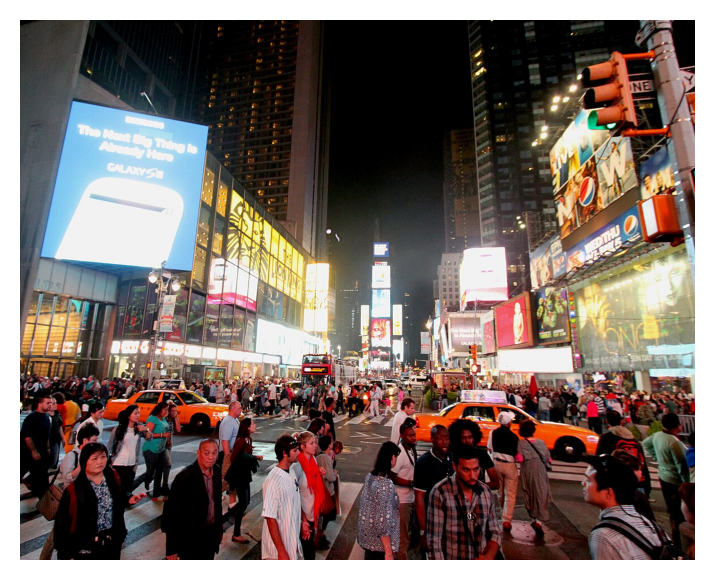

**gemini-3.1-pro-preview** &nbsp;|&nbsp; 11.2s &nbsp;|&nbsp; 684 tok

```json
[
  {"box_2d": [784, 49, 999, 159], "label": "person"},
  {"box_2d": [763, 396, 995, 459], "label": "person"},
  {"box_2d": [791, 591, 999, 715], "label": "person"},
  {"box_2d": [773, 214, 999, 313], "label": "person"},
  {"box_2d": [796, 822, 999, 963], "label": "person"},
  {"box_2d": [722, 919, 988, 995], "label": "person"},
  {"box_2d": [743, 725, 963, 792], "label": "person"},
  {"box_2d": [735, 303, 971, 357], "label": "person"},
  {"box_2d": [712, 131, 903, 190], "label": "person"},
  {"box_2d": [782, 494, 998, 574], "label": "person"},
  {"box_2d": [747, 577, 989, 642], "label": "person"},
  {"box_2d": [769, 350, 999, 423], "label": "person"},
  {"box_2d": [724, 692, 936, 745], "label": "person"},
  {"box_2d": [706, 178, 885, 230], "label": "person"},
  {"box_2d": [693, 2, 889, 58], "label": "person"},
  {"box_2d": [763, 436, 981, 477], "label": "person"},
  {"box_2d": [743, 547, 995, 595], "label": "person"},
  {"box_2d": [717, 850, 893, 936], "label": "person"},
  {"box_2d": [697, 546, 786, 588], "label": "person"},
  {"box_2d": [706, 292, 866, 332], "label": "person"}
]
```

**gemini-3.1-flash-lite-preview** &nbsp;|&nbsp; 5.4s &nbsp;|&nbsp; 620 tok

[{"point": [778, 25], "label": "person"}, {"point": [735, 75], "label": "person"}, {"point": [743, 105], "label": "person"}, {"point": [772, 85], "label": "person"}, {"point": [845, 126], "label": "person"}, {"point": [777, 163], "label": "person"}, {"point": [757, 218], "label": "person"}, {"point": [837, 246], "label": "person"}, {"point": [763, 311], "label": "person"}, {"point": [793, 335], "label": "person"}, {"point": [832, 381], "label": "person"}, {"point": [817, 437], "label": "person"}, {"point": [805, 461], "label": "person"}, {"point": [763, 442], "label": "person"}, {"point": [730, 461], "label": "person"}, {"point": [743, 560], "label": "person"}, {"point": [793, 580], "label": "person"}, {"point": [820, 552], "label": "person"}, {"point": [805, 608], "label": "person"}, {"point": [870, 645], "label": "person"}, {"point": [777, 665], "label": "person"}, {"point": [763, 725], "label": "person"}, {"point": [793, 745], "label": "person"}, {"point": [742, 875], "label": "person"}, {"point": [775, 960], "label": "person"}, {"point": [870, 895], "label": "person"}, {"point": [712, 850], "label": "person"}, {"point": [705, 900], "label": "person"}, {"point": [698, 775], "label": "person"}, {"point": [683, 375], "label": "person"}, {"box_2d": [702, 532, 735, 552], "label": "person"}, {"point": [677, 513], "label": "person"}]

**gemma-4-31b-it** &nbsp;|&nbsp; 36.1s &nbsp;|&nbsp; 548 tok

```json
[
  {"box_2d": [711, 0, 897, 57], "label": "person"},
  {"box_2d": [800, 48, 998, 154], "label": "person"},
  {"box_2d": [805, 210, 998, 303], "label": "person"},
  {"box_2d": [811, 354, 998, 423], "label": "person"},
  {"box_2d": [806, 391, 998, 454], "label": "person"},
  {"box_2d": [805, 486, 998, 562], "label": "person"},
  {"box_2d": [793, 592, 998, 708], "label": "person"},
  {"box_2d": [756, 713, 968, 786], "label": "person"},
  {"box_2d": [817, 834, 998, 956], "label": "person"},
  {"box_2d": [744, 932, 913, 986], "label": "person"},
  {"box_2d": [754, 555, 988, 606], "label": "person"},
  {"box_2d": [723, 162, 886, 214], "label": "person"},
  {"box_2d": [718, 133, 858, 177], "label": "person"},
  {"box_2d": [705, 336, 815, 376], "label": "person"},
  {"box_2d": [700, 301, 811, 342], "label": "person"},
  {"box_2d": [708, 262, 823, 301], "label": "person"}
]
```

**gemma-4-26b-a4b-it** &nbsp;|&nbsp; 73.8s &nbsp;|&nbsp; 928 tok

```json
[
  {"box_2d": [715, 418, 848, 457], "label": "person"},
  {"box_2d": [705, 857, 811, 901], "label": "person"},
  {"box_2d": [715, 551, 876, 606], "label": "person"},
  {"box_2d": [712, 831, 816, 871], "label": "person"},
  {"box_2d": [746, 931, 911, 998], "label": "person"},
  {"box_2d": [752, 714, 996, 794], "label": "person"},
  {"box_2d": [757, 833, 1000, 975], "label": "person"},
  {"box_2d": [763, 376, 1000, 445], "label": "person"},
  {"box_2d": [765, 593, 1000, 706], "label": "person"},
  {"box_2d": [775, 351, 1000, 416], "label": "person"},
  {"box_2d": [775, 204, 1000, 316], "label": "person"},
  {"box_2d": [776, 45, 1000, 164], "label": "person"},
  {"box_2d": [776, 472, 1000, 572], "label": "person"},
  {"box_2d": [687, 342, 793, 381], "label": "person"},
  {"box_2d": [687, 683, 762, 724], "label": "person"},
  {"box_2d": [688, 319, 790, 356], "label": "person"},
  {"box_2d": [691, 522, 794, 562], "label": "person"},
  {"box_2d": [692, 437, 806, 474], "label": "person"},
  {"box_2d": [694, 276, 828, 318], "label": "person"},
  {"box_2d": [694, 392, 791, 427], "label": "person"},
  {"box_2d": [695, 497, 783, 533], "label": "person"},
  {"box_2d": [701, 0, 886, 67], "label": "person"},
  {"box_2d": [701, 71, 839, 121], "label": "person"},
  {"box_2d": [706, 931, 856, 997], "label": "person"},
  {"box_2d": [711, 452, 812, 494], "label": "person"},
  {"box_2d": [712, 115, 875, 167], "label": "person"},
  {"box_2d": [712, 171, 913, 236], "label": "person"}
]
```


⏱ Wall: 73.8s (parallel) vs 126.4s (sequential would be)


In [9]:
detect_img = Image.open('crowd2.jpg')

results_detect = compare(
    """Detect all people in this image.
Return a JSON array: [{"label": "person", "box_2d": [y_min, x_min, y_max, x_max]}]
Coordinates in [0, 1000] range.
Return ONLY the JSON array, no explanation.""",
    images=[detect_img],
)

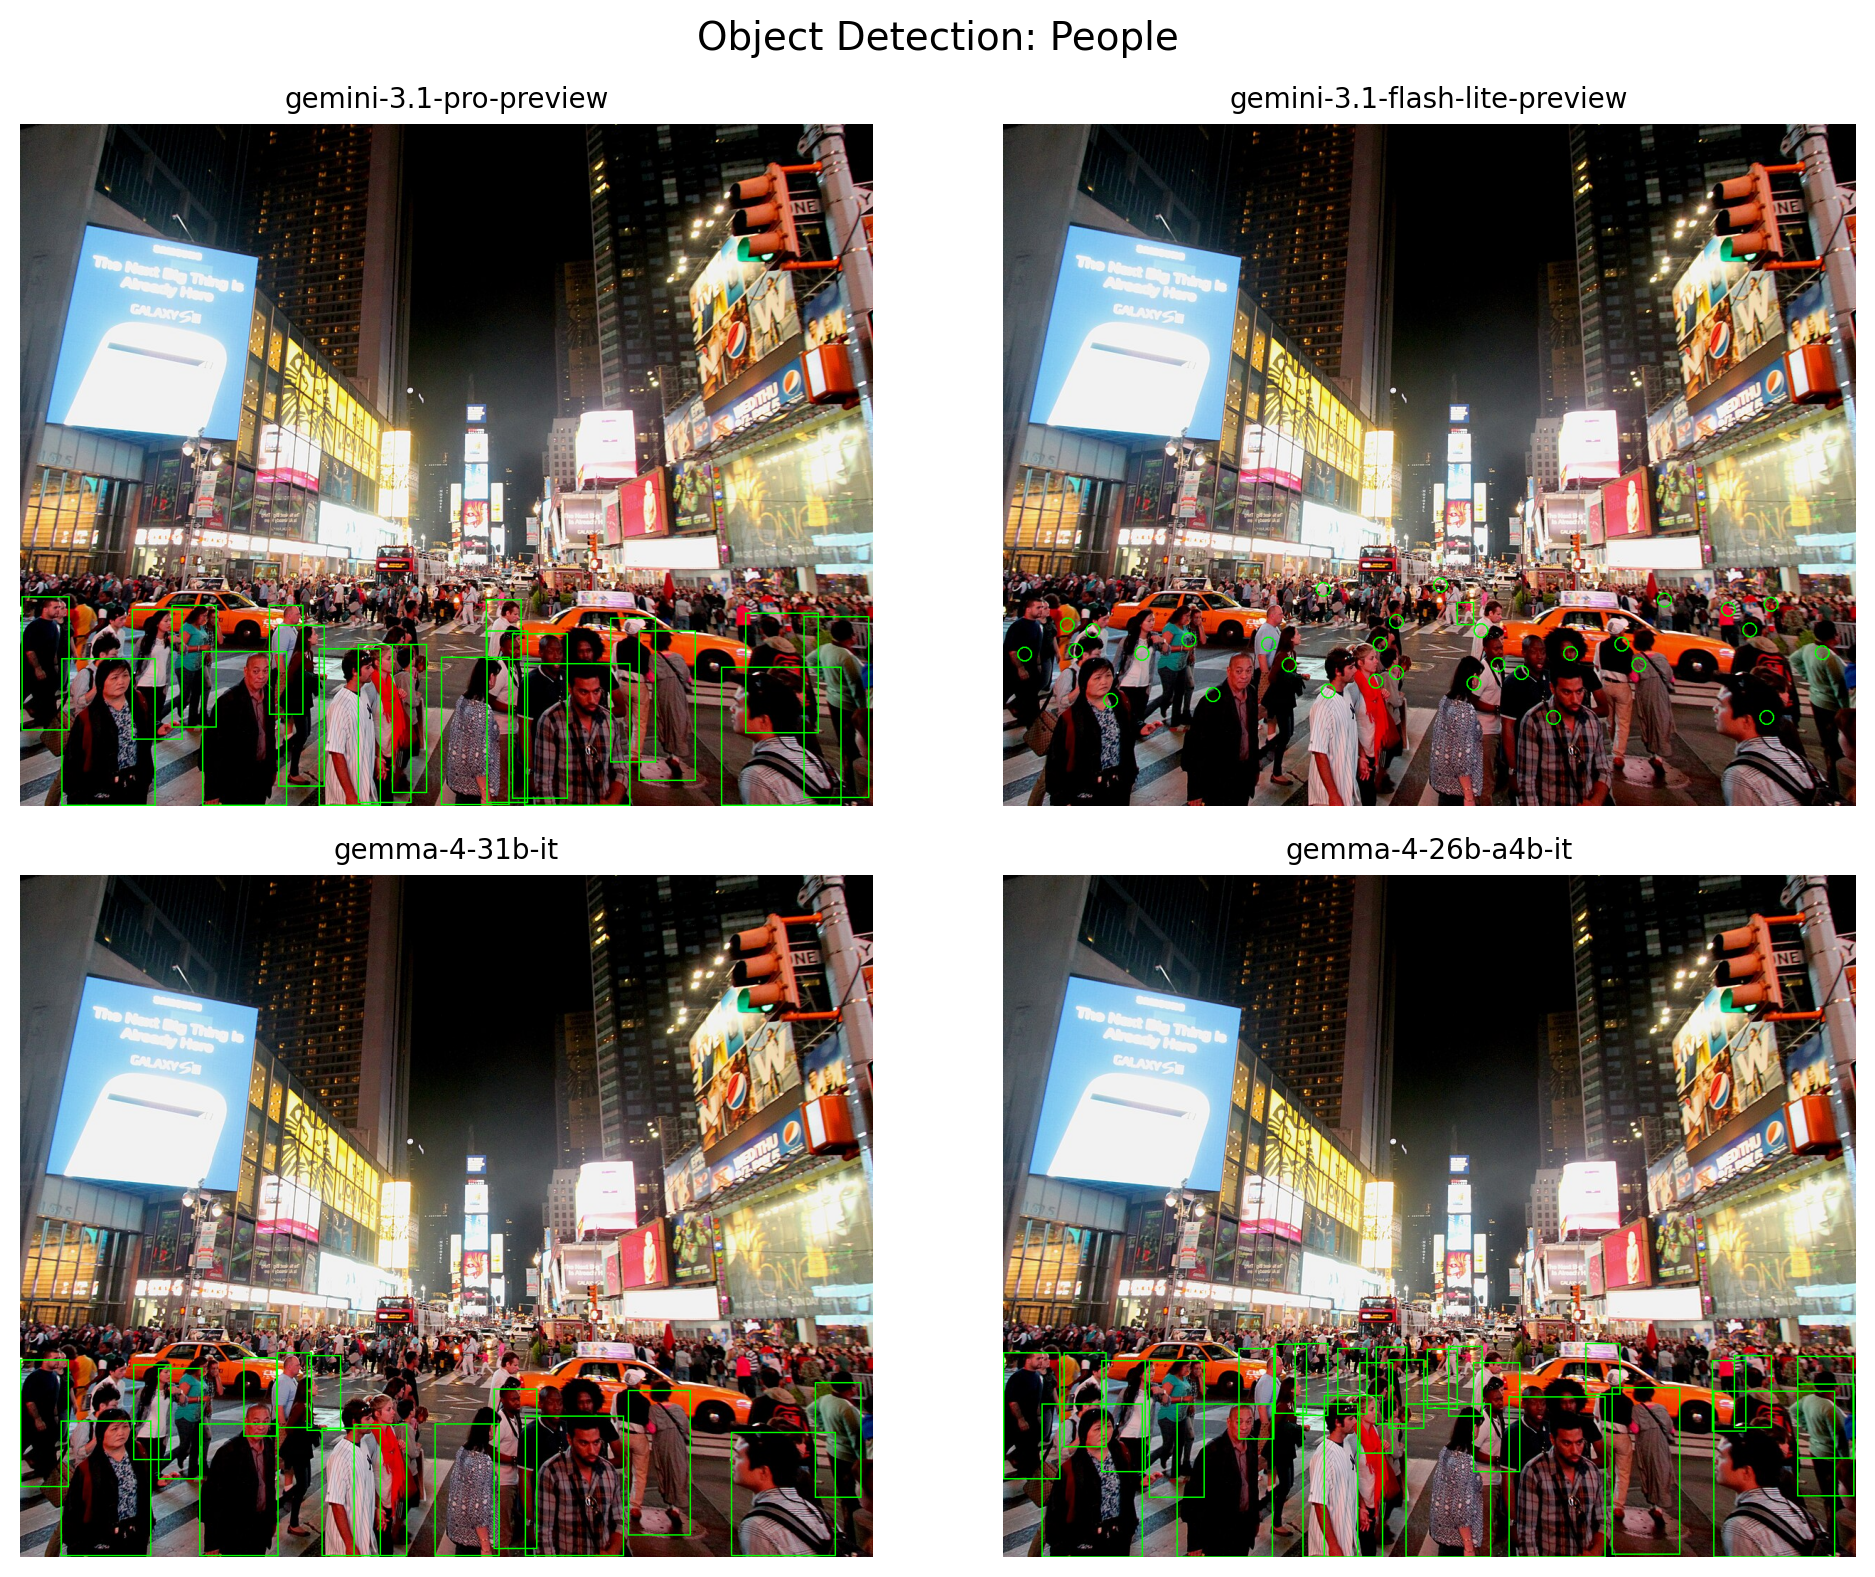

In [10]:
img_np = np.array(detect_img); h, w = img_np.shape[:2]
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for ax, model in zip(axes.flat, MODELS):
    ax.set_title(SHORT[model], fontsize=10)
    resp = results_detect[model]['response'].strip()
    resp = re.sub(r'```json\s*', '', resp)
    resp = re.sub(r'```', '', resp)
    try:
        m = re.search(r'\[.*\]', resp, re.DOTALL)
        dets = json.loads(m.group() if m else resp)
        pil = Image.fromarray(img_np.copy())
        draw = ImageDraw.Draw(pil)
        n_drawn = 0
        for d in dets:
            if not isinstance(d, dict):
                continue
            box = d.get('box') or d.get('bbox') or d.get('box_2d') or d.get('bounding_box')
            if box and len(box) == 4:
                y1, x1, y2, x2 = box
                draw.rectangle([x1*w/1000, y1*h/1000, x2*w/1000, y2*h/1000], outline='lime', width=2)
                n_drawn += 1
            elif 'point' in d and isinstance(d.get('point'), list) and len(d['point']) == 2:
                py, px = d['point']
                cx, cy = px*w/1000, py*h/1000
                draw.ellipse([cx-10, cy-10, cx+10, cy+10], outline='lime', width=2)
                n_drawn += 1
        ax.imshow(np.array(pil))
        ax.set_xlabel(f"{n_drawn} detections")
    except Exception as e:
        ax.imshow(img_np)
        ax.set_xlabel("parse error")
    ax.axis('off')
plt.suptitle("Object Detection: People", fontsize=14); plt.tight_layout(); plt.show()

## Task 5: Change Detection

Two images of the same area — what changed? This tests multi-image reasoning. Note: some models may struggle with multiple images in a single prompt.

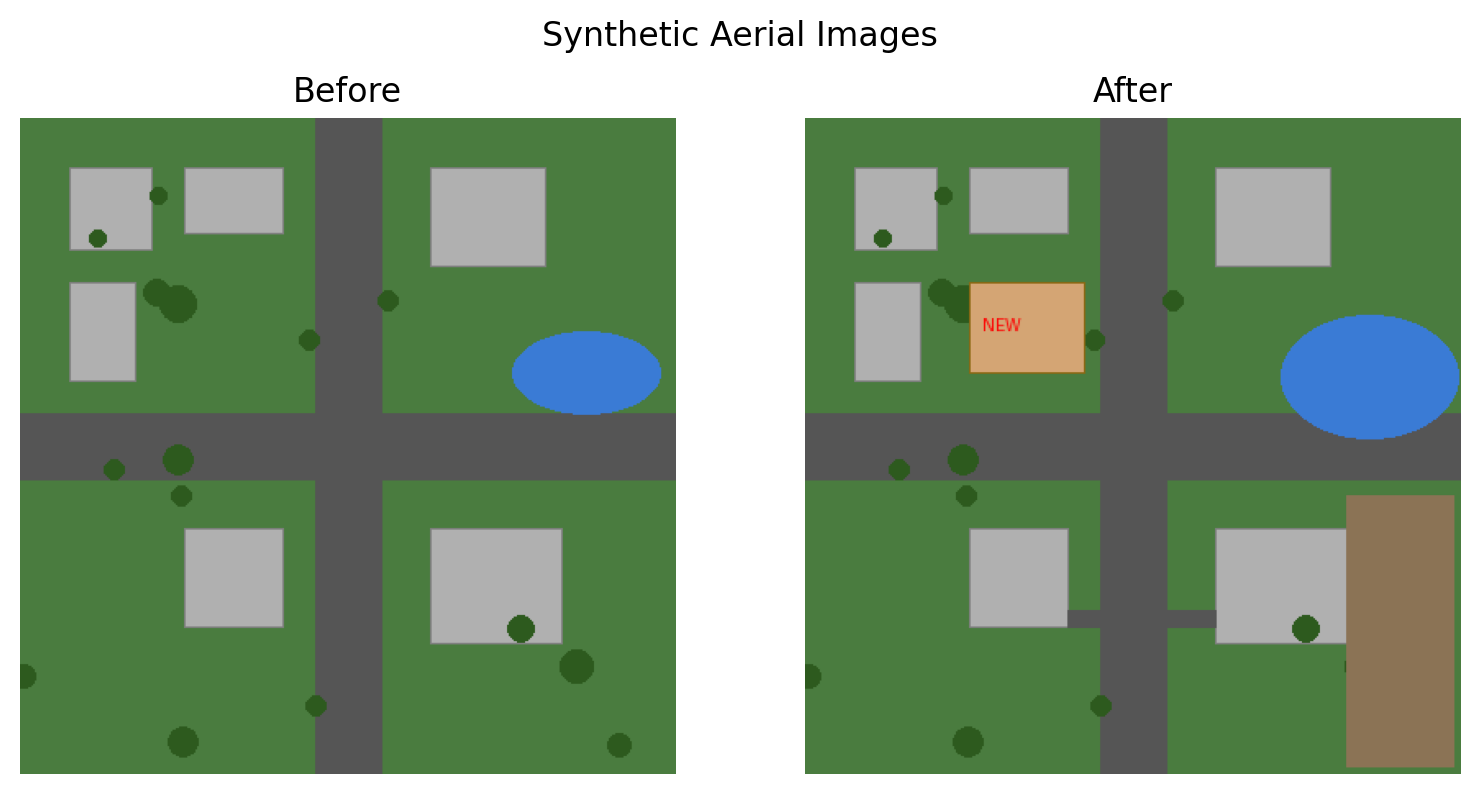

In [11]:
# Synthetic before/after aerial images
np.random.seed(123)
S = 400

def make_aerial():
    img = Image.new('RGB', (S, S), '#4a7c3f')
    d = ImageDraw.Draw(img)
    d.rectangle([180, 0, 220, S], fill='#555')  # vertical road
    d.rectangle([0, 180, S, 220], fill='#555')  # horizontal road
    for b in [(30,30,80,80),(100,30,160,70),(30,100,70,160),
              (250,30,320,90),(250,250,330,320),(100,250,160,310)]:
        d.rectangle(b, fill='#b0b0b0', outline='#808080')
    for _ in range(15):
        x, y = np.random.randint(0, S, 2)
        r = np.random.randint(5, 12)
        d.ellipse([x-r, y-r, x+r, y+r], fill='#2d5a1e')
    d.ellipse([300, 130, 390, 180], fill='#3a7bd5')  # pond
    return img

before = make_aerial()
after = before.copy()
d = ImageDraw.Draw(after)
d.rectangle([100, 100, 170, 155], fill='#d4a574', outline='#8b6914')  # new building
d.text((108, 120), "NEW", fill='red')
d.rectangle([330, 230, 395, 395], fill='#8b7355')  # deforestation
d.ellipse([290, 120, 398, 195], fill='#3a7bd5')  # expanded water
d.rectangle([160, 300, 250, 310], fill='#555')  # new road

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
ax1.imshow(before); ax1.set_title('Before'); ax1.axis('off')
ax2.imshow(after); ax2.set_title('After'); ax2.axis('off')
plt.suptitle('Synthetic Aerial Images'); plt.tight_layout(); plt.show()

In [12]:
results_change = compare(
    """These are 'before' (first) and 'after' (second) aerial images of the same area.
List every change you detect. For each change specify:
- What changed (added/removed/modified)
- Where (use quadrant: top-left, center, bottom-right, etc.)
Bullet points only, be specific.""",
    images=[before, after],
    display_images=False,
)

**gemini-3.1-pro-preview** &nbsp;|&nbsp; 14.5s &nbsp;|&nbsp; 130 tok

Based on the comparison of the two images, here are the changes detected:

*   **Added:** A tan rectangular building with red text reading "NEW" appeared in the **top-left quadrant**.
*   **Added:** A small gray rectangular path/driveway connecting the square gray building to the vertical road appeared in the **bottom-left quadrant**.
*   **Added:** A small gray rectangular path/driveway connecting the square gray building to the vertical road appeared in the **bottom-right quadrant**.
*   **Added:** A large brown rectangular building appeared on the far right side of the **bottom-right quadrant**.

**gemini-3.1-flash-lite-preview** &nbsp;|&nbsp; 2.0s &nbsp;|&nbsp; 81 tok

Based on the comparison between the two images, here are the changes detected:

*   **Added:** A new rectangular building labeled "NEW" in the **top-left** quadrant, positioned between the two existing gray buildings and the vertical road.
*   **Added:** A large, tall brown rectangular structure in the **bottom-right** quadrant, located to the right of the gray building.

**gemma-4-31b-it** &nbsp;|&nbsp; 19.9s &nbsp;|&nbsp; 36 tok

* Modified: grey rectangle changed to an orange rectangle with the text "NEW" in the top-left quadrant.
* Added: brown rectangle in the bottom-right quadrant.

**gemma-4-26b-a4b-it** &nbsp;|&nbsp; 56.4s &nbsp;|&nbsp; 49 tok

It appears that only one image was provided. To detect and list changes, I need both the **'before'** and **'after'** images to compare. 

Please upload both images so I can perform the analysis for you.


⏱ Wall: 56.4s (parallel) vs 92.8s (sequential would be)


## Task 6: Structured JSON Extraction

Gemini supports `response_schema` for guaranteed valid JSON. Gemma needs prompt-based extraction — does it still produce valid JSON?

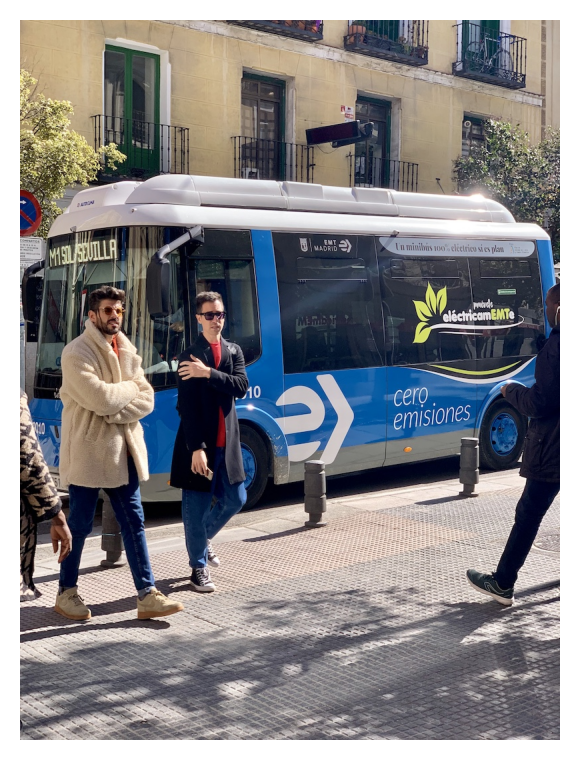

**gemini-3.1-pro-preview** (5.7s)

{
  "scene": "A daytime street scene featuring a blue and grey electric minibus stopped at a curb, with three men walking past it on a tiled sidewalk.",
  "people_count": 3,
  "text_visible": [
    "M1",
    "SOL",
    "SEVILLA",
    "AUTOCAR",
    "EMT MADRID",
    "Un minibus 100% electrico si es plan",
    "el\u00e9ctricaMEMTe",
    "10",
    "cero",
    "emisiones"
  ]
}


**gemini-3.1-flash-lite-preview** (3.5s)

{
  "scene": "A city street scene featuring people walking in front of an electric bus in Madrid.",
  "people_count": 3,
  "text_visible": [
    "M1 SOL / SEVILLA",
    "EMT MADRID",
    "Un minibus 100% el\u00e9ctrico s\u00ed es plan",
    "mu\u00e9vete el\u00e9ctricamEMTe",
    "10",
    "cero emisiones"
  ]
}


**gemma-4-31b-it** (21.7s)

{
  "scene": "A city street scene featuring a blue and white bus with promotional text and several people standing around it.",
  "people_count": 4,
  "text_visible": [
    "TOUR MADRID",
    "La movilidad sostenible es la plan",
    "estamos",
    "elcompromiso",
    "cero emisiones"
  ]
}


**gemma-4-26b-a4b-it** (14.7s)

{
  "scene": "A street scene with people walking past a large blue and white bus.",
  "people_count": 4,
  "text_visible": [
    "FERRILLO",
    "cero emisiones",
    "eltransporte",
    "0"
  ]
}


In [13]:
bus_img = Image.open('bus.jpg')

schema_config = types.GenerateContentConfig(
    response_mime_type="application/json",
    response_schema={
        "type": "OBJECT",
        "properties": {
            "scene": {"type": "STRING"},
            "people_count": {"type": "INTEGER"},
            "text_visible": {"type": "ARRAY", "items": {"type": "STRING"}},
        },
        "required": ["scene", "people_count", "text_visible"],
    },
)

prompt_base = "Describe this scene. How many people? What text is visible?"
prompt_gemma = prompt_base + '\nReturn ONLY valid JSON: {"scene": "...", "people_count": int, "text_visible": ["..."]}'

async def _json_task():
    tasks = []
    for m in MODELS:
        if 'gemma' in m:
            tasks.append(_call_one(m, [bus_img, prompt_gemma]))
        else:
            tasks.append(_call_one(m, [bus_img, prompt_base], config=schema_config))
    return dict(await asyncio.gather(*tasks))

try:
    loop = asyncio.get_running_loop()
    import nest_asyncio; nest_asyncio.apply()
    results_json = loop.run_until_complete(_json_task())
except RuntimeError:
    results_json = asyncio.run(_json_task())

fig, ax = plt.subplots(figsize=(3, 4))
ax.imshow(bus_img); ax.axis('off'); plt.tight_layout(); plt.show()

for model, r in results_json.items():
    display(Markdown(f"**{SHORT[model]}** ({r['time']})"))
    try:
        raw = r['response'].strip()
        raw = re.sub(r'```json\s*', '', raw)
        raw = re.sub(r'```', '', raw)
        parsed = json.loads(raw)
        print(json.dumps(parsed, indent=2))
    except:
        print(f"[Invalid JSON] {r['response'][:200]}")

## Summary: Time & Tokens

In [14]:
all_tasks = {
    "Scene": results_scene,
    "Chart": results_chart,
    "Segment": results_seg,
    "Detect": results_detect,
    "Change": results_change,
    "JSON": results_json,
}

rows = []
for task, results in all_tasks.items():
    for model, r in results.items():
        in_t = r["in_tok"] if isinstance(r["in_tok"], int) else 0
        out_t = r["out_tok"] if isinstance(r["out_tok"], int) else 0
        rows.append({
            "Task": task, "Model": SHORT[model],
            "Time": r["time"], "In Tok": in_t, "Out Tok": out_t,
        })

df = pd.DataFrame(rows)

display(Markdown("### Response Time"))
display(df.pivot(index="Task", columns="Model", values="Time").rename_axis(None, axis=1))

display(Markdown("### Output Tokens"))
display(df.pivot(index="Task", columns="Model", values="Out Tok").rename_axis(None, axis=1))

### Response Time

,gemini-3.1-flash-lite-preview,gemini-3.1-pro-preview,gemma-4-26b-a4b-it,gemma-4-31b-it
Task,,,,
Change,2.0s,14.5s,56.4s,19.9s
Chart,3.1s,13.3s,16.8s,18.0s
Detect,5.4s,11.2s,73.8s,36.1s
JSON,3.5s,5.7s,14.7s,21.7s
Scene,2.3s,12.1s,17.7s,8.4s
Segment,4.0s,7.5s,55.9s,114.8s


### Output Tokens

,gemini-3.1-flash-lite-preview,gemini-3.1-pro-preview,gemma-4-26b-a4b-it,gemma-4-31b-it
Task,,,,
Change,81,130,49,36
Chart,129,126,105,96
Detect,620,684,928,548
JSON,104,132,53,69
Scene,54,84,47,59
Segment,199,390,207,395


### Aggregate per Model

,Total_Input_Tokens,Total_Output_Tokens,Total_Time_s
Model,,,
gemini-3.1-flash-lite-preview,7812,1187,20.0s
gemini-3.1-pro-preview,7812,1546,64.0s
gemma-4-26b-a4b-it,2116,1389,235.0s
gemma-4-31b-it,2116,1203,219.0s


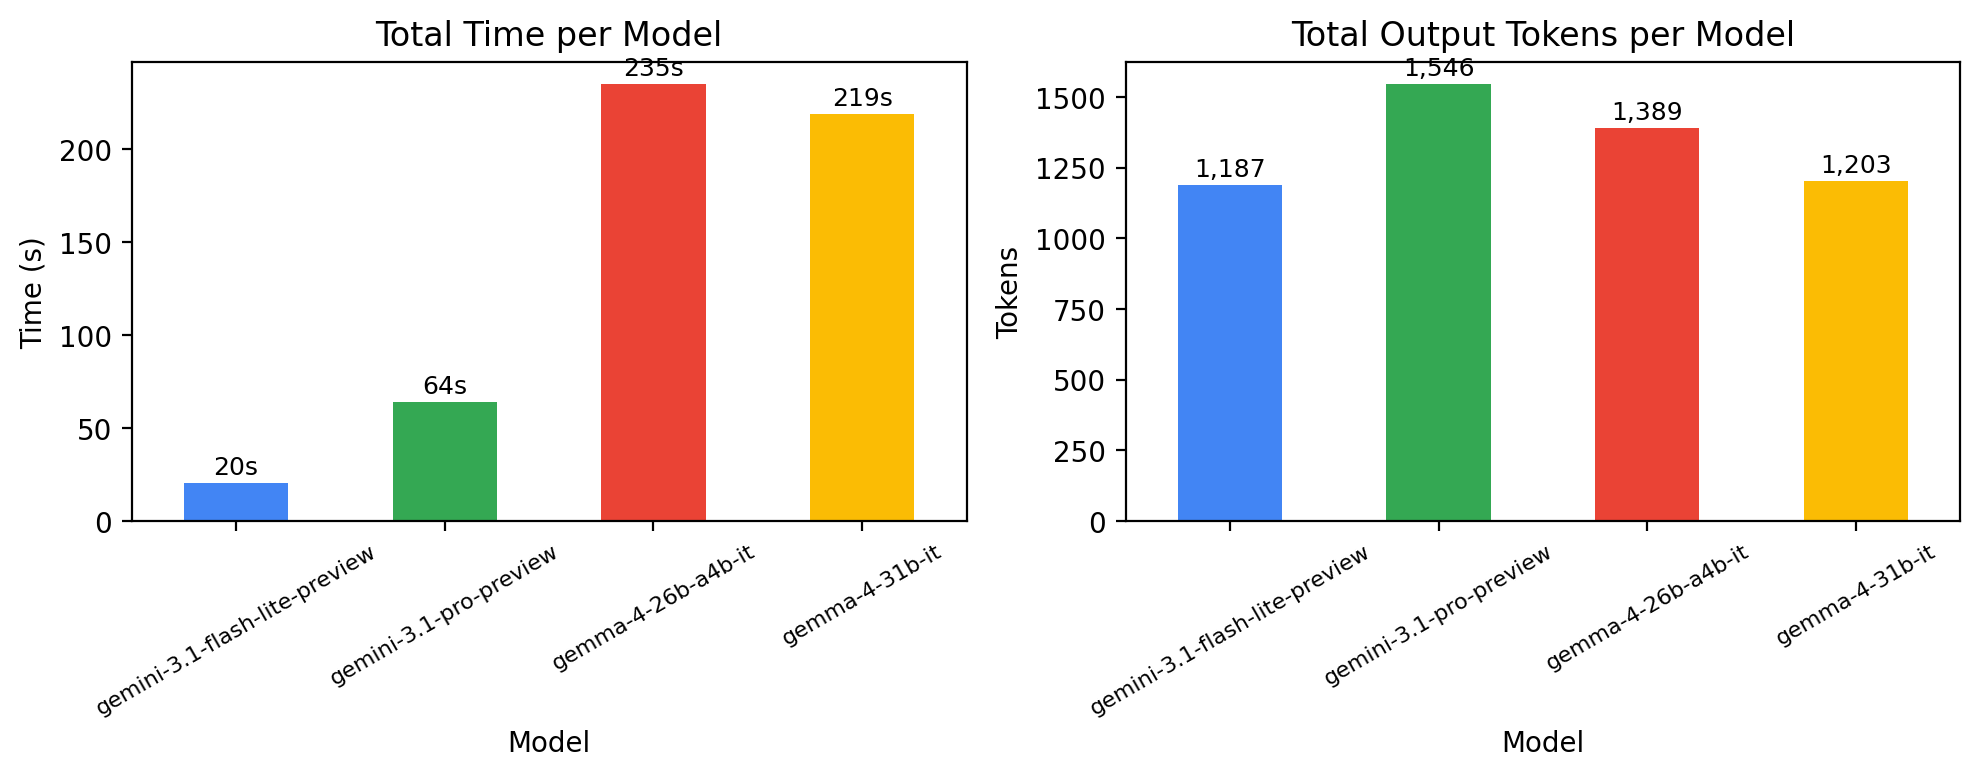

In [15]:
# Aggregate per model
agg = df.groupby('Model').agg(
    Total_Input_Tokens=('In Tok', 'sum'),
    Total_Output_Tokens=('Out Tok', 'sum'),
    Total_Time_s=('Time', lambda x: sum(float(t.replace('s','').replace('err','0')) for t in x)),
).round(0)
agg['Total_Time_s'] = agg['Total_Time_s'].apply(lambda x: f"{x:.1f}s")

display(Markdown("### Aggregate per Model"))
display(agg)

# Bar chart of time and tokens
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
colors = ['#4285f4', '#34a853', '#ea4335', '#fbbc04']

time_vals = df.groupby('Model')['Time'].apply(
    lambda x: sum(float(t.replace('s','').replace('err','0')) for t in x)
)
time_vals.plot.bar(ax=ax1, color=colors)
ax1.set_ylabel('Time (s)'); ax1.set_title('Total Time per Model')
ax1.tick_params(axis='x', rotation=30, labelsize=8)
for i, v in enumerate(time_vals):
    ax1.text(i, v + max(time_vals)*0.02, f'{v:.0f}s', ha='center', fontsize=9)

tok_vals = df.groupby('Model')['Out Tok'].sum()
tok_vals.plot.bar(ax=ax2, color=colors)
ax2.set_ylabel('Tokens'); ax2.set_title('Total Output Tokens per Model')
ax2.tick_params(axis='x', rotation=30, labelsize=8)
for i, v in enumerate(tok_vals):
    ax2.text(i, v + max(tok_vals)*0.02, f'{v:,.0f}', ha='center', fontsize=9)

plt.tight_layout(); plt.show()

## Takeaways

- **Same API, open vs closed** — `google-genai` SDK works for both; switching is just a model name change
- **Apache 2.0** — Gemma 4 can be fine-tuned and self-hosted (great for sensitive data)
- **Async is essential** — running 4 models in parallel with `client.aio` saves 3-4x wall time
- **Structured output** — Gemini supports `response_schema` for guaranteed JSON; Gemma needs prompt engineering
- **Multi-image gaps** — `gemma-4-26b-a4b-it` refused the change detection task, claiming it could only see one image. Multi-image prompts work better with Gemini and the larger Gemma model
- **Output format fragility** — models use different JSON keys for the same concept (e.g. `box` vs `box_2d` vs `bbox` for bounding boxes). Robust parsing is essential
- **Speed** — Gemini Flash Lite is ~10x faster than Gemma models on the API; Gemma models are slow (50-80s per call) likely due to serving infrastructure